In [1]:
import kagglehub
from PIL import Image
import torch
import matplotlib.pyplot as plt
import util
from graphs import plot_loss_flattening
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
from models.resnet import run

path = "./normalized_images"

num_epochs = 8
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True)

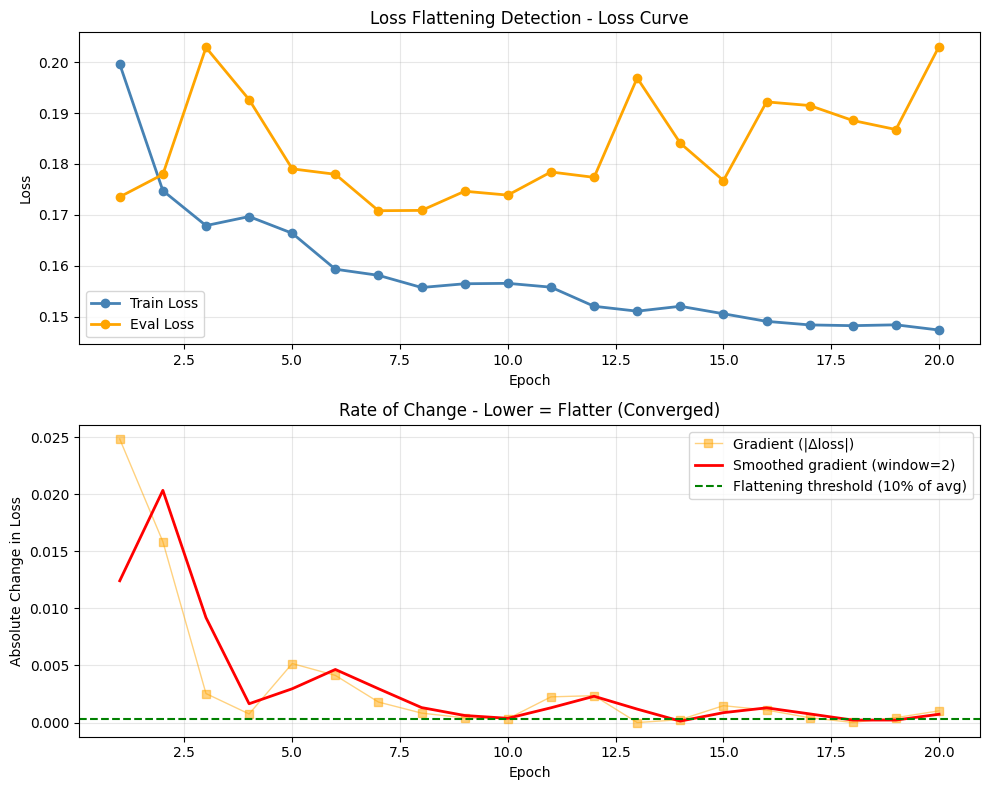


✓ Loss appears to flatten starting around epoch 14


In [4]:
plot_loss_flattening(train_losses, eval_losses, window_size=2)


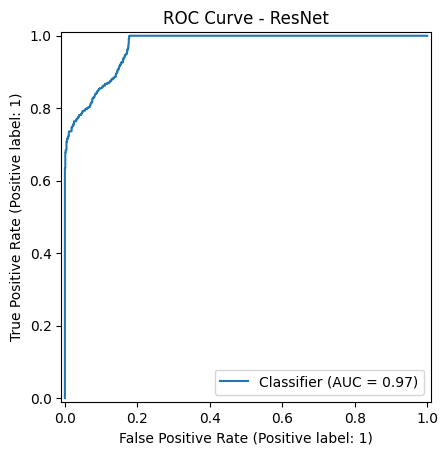

In [5]:

RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - ResNet")
plt.show()

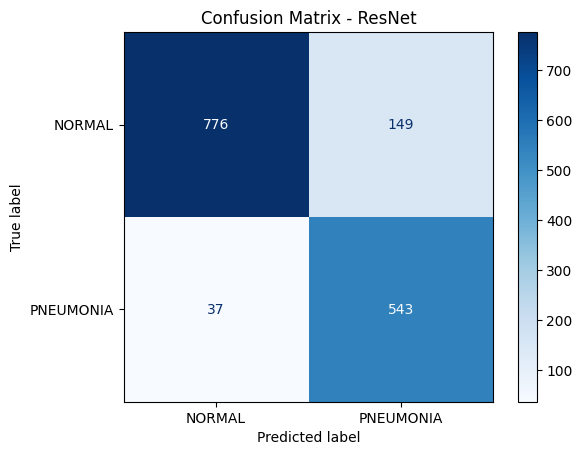

In [6]:

ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - ResNet")
plt.show()

# ResNet Testing================

In [ ]:
RocCurveDisplay.from_predictions(test_labels, test_preds)
plt.title("ROC Curve - ResNet (Test Set)")
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - ResNet (Test Set)")
plt.show()